In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/deploypilot_ai_ci_cd_pipeline_dataset.csv")

In [3]:
type(df)

pandas.DataFrame

In [4]:
df.head()

,pipeline_id,run_id,timestamp,ci_tool,repository,branch,commit_hash,author,language,os,...,retry_count,is_flaky_test,rollback_triggered,incident_created,result,commit_size,files_changed,warnings,tests_failed,previous_failure_rate
0,ado-feature-store-nightly-regression,20260619.24,2026-04-28T22:44:00,Azure DevOps,mlops/feature-store,develop,b61ba350873af319212adfadb5dc5a6dfd856d83,akash_mlops,Python,windows-latest,...,0,False,False,False,FAIL,3,7,2,0,0.207
1,jenkins-e2e-test-suite-release,e2e-test-suite/feature-pagos#22855,2026-04-17T06:51:00,Jenkins,qa/e2e-test-suite,feature/pagos,99568baae90d2f0893079353e02d580f9f454ef2,data_pipeline_bot,C++,ubuntu-latest,...,3,False,False,False,FAIL,62,22,24,0,0.309
2,gha-analytics-etl-build-test-deploy,118001076740-1,2026-04-25T16:49:00,GitHub Actions,data/analytics-etl,release/2026.07,2d023683742031c29712d7960be4e9ddc2d1533f,data_pipeline_bot,Go,windows-latest,...,0,False,False,False,FAIL,11,5,0,0,0.093
3,circleci-billing-api-security-scan,9e8ff9ec-6682-5f20-8fa4-9cead21c4a5e,2025-12-19T06:58:00,CircleCI,finance/billing-api,bugfix/payment-webhook,abc701170de64d4c390f57460c1e991999612d0f,junior_juan,Java,ubuntu-latest,...,0,False,False,False,PASS,28,11,1,0,0.046
4,jenkins-deploypilot-ai-deploy-staging,deploypilot-ai/bugfix-flaky-login-test#30551,2026-05-12T01:32:00,Jenkins,devops/deploypilot-ai,bugfix/flaky-login-test,bb4190851815f62664fa796aa525e364b001004b,nimal_backend,C++,macos-latest,...,3,False,False,True,FAIL,35,11,3,0,0.821


In [5]:
df.tail()

,pipeline_id,run_id,timestamp,ci_tool,repository,branch,commit_hash,author,language,os,...,retry_count,is_flaky_test,rollback_triggered,incident_created,result,commit_size,files_changed,warnings,tests_failed,previous_failure_rate
19995,gitlab-fraud-detection-api-build-test-deploy,pipeline/923241/job/2195134,2025-12-18T03:08:00,GitLab CI,platform-team/fraud-detection-api,ci/cd-proyecto,92bdd1797a3066c0dd59cad1f92fbdba75e9c672,security_scan_bot,Rust,windows-latest,...,1,False,False,False,PASS,25,1,4,0,0.122
19996,circleci-order-fulfillment-service-pr-validation,4a6c3a0a-6ef1-57d5-9aaa-96782506e51f,2026-05-16T16:54:00,CircleCI,commerce/order-fulfillment-service,feature/order-events,37b1264e619ac1ed4e1a75ef4ca665cdc7e16351,akash_mlops,Java,macos-latest,...,0,False,False,False,FAIL,33,2,4,0,0.355
19997,gha-helm-charts-ci,118001023698-3,2026-06-07T20:00:00,GitHub Actions,infra/helm-charts,release/2026.06,cbe461e2e98ffa2d6b073564d2e03dc61829c46c,devops-bot,NodeJS,ubuntu-latest,...,1,False,False,False,FAIL,25,42,1,0,0.794
19998,gha-reporting-dashboard-build-test-deploy,118000839811-1,2026-04-24T00:11:00,GitHub Actions,reporting/reporting-dashboard,release/2026.07,c99ad98ccf66df6ffecd01e78baf2368394008b6,data_pipeline_bot,Python,ubuntu-latest,...,3,False,False,False,FAIL,88,29,19,0,0.638
19999,ado-notification-service-build-test-deploy,20260622.9,2025-12-12T13:27:00,Azure DevOps,messaging/notification-service,hotfix/urgent-rollout,35990696498a57e966345e139880889b43859b52,maria_sre,Python,ubuntu-latest,...,1,False,False,False,PASS,14,8,4,0,0.259


In [6]:
df.shape

(20000, 31)

In [7]:
df.columns

Index(['pipeline_id', 'run_id', 'timestamp', 'ci_tool', 'repository', 'branch',
       'commit_hash', 'author', 'language', 'os', 'cloud_provider',
       'build_duration_sec', 'test_duration_sec', 'deploy_duration_sec',
       'failure_stage', 'failure_type', 'error_code', 'error_message',
       'severity', 'cpu_usage_pct', 'memory_usage_mb', 'retry_count',
       'is_flaky_test', 'rollback_triggered', 'incident_created', 'result',
       'commit_size', 'files_changed', 'warnings', 'tests_failed',
       'previous_failure_rate'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pipeline_id            20000 non-null  str    
 1   run_id                 20000 non-null  str    
 2   timestamp              20000 non-null  str    
 3   ci_tool                20000 non-null  str    
 4   repository             20000 non-null  str    
 5   branch                 20000 non-null  str    
 6   commit_hash            20000 non-null  str    
 7   author                 20000 non-null  str    
 8   language               20000 non-null  str    
 9   os                     20000 non-null  str    
 10  cloud_provider         19268 non-null  str    
 11  build_duration_sec     20000 non-null  int64  
 12  test_duration_sec      20000 non-null  int64  
 13  deploy_duration_sec    20000 non-null  int64  
 14  failure_stage          10000 non-null  str    
 15  failure_type 

In [9]:
df.isnull().sum()

pipeline_id                  0
run_id                       0
timestamp                    0
ci_tool                      0
repository                   0
branch                       0
commit_hash                  0
author                       0
language                     0
os                           0
cloud_provider             732
build_duration_sec           0
test_duration_sec            0
deploy_duration_sec          0
failure_stage            10000
failure_type             10000
error_code               10000
error_message                0
severity                 10000
cpu_usage_pct                0
memory_usage_mb              0
retry_count                  0
is_flaky_test                0
rollback_triggered           0
incident_created             0
result                       0
commit_size                  0
files_changed                0
warnings                     0
tests_failed                 0
previous_failure_rate        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,build_duration_sec,test_duration_sec,deploy_duration_sec,cpu_usage_pct,memory_usage_mb,retry_count,commit_size,files_changed,warnings,tests_failed,previous_failure_rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,708.427600,569.042350,366.345200,55.712633,7948.594050,1.14340,33.346250,14.286400,5.111500,0.388400,0.351597
std,547.673856,443.076434,336.055567,21.355089,6910.315705,1.15265,25.162643,11.913957,4.558312,2.075129,0.243518
min,30.000000,10.000000,0.000000,12.000000,256.000000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,318.000000,239.000000,109.000000,40.130000,2802.000000,0.00000,14.000000,5.000000,2.000000,0.000000,0.168000
50%,574.000000,443.000000,284.000000,55.685000,5122.000000,1.00000,26.000000,10.000000,4.000000,0.000000,0.285500
75%,968.000000,820.000000,491.000000,70.982500,12140.500000,2.00000,50.000000,22.000000,8.000000,0.000000,0.525000
max,3594.000000,2398.000000,1799.000000,98.990000,32749.000000,5.00000,94.000000,44.000000,24.000000,17.000000,0.920000


In [12]:
import seaborn as sns

In [13]:
df['result'].value_counts()

result
FAIL    10000
PASS    10000
Name: count, dtype: int64

In [14]:
df['result'].value_counts()/df.shape[0]*100

result
FAIL    50.0
PASS    50.0
Name: count, dtype: float64

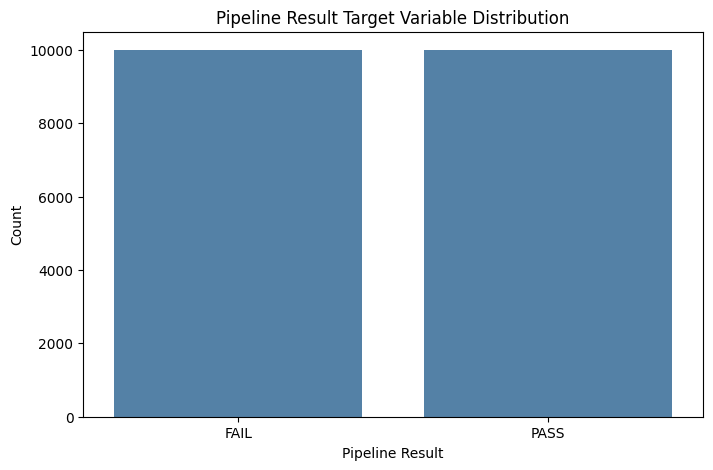

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='result', data=df, color='steelblue')

plt.title("Pipeline Result Target Variable Distribution")
plt.xlabel("Pipeline Result")
plt.ylabel("Count")
plt.show()

In [16]:
print("Unique pipeline IDs:")
print(df['pipeline_id'].nunique())

print("Total rows:")
print(df.shape[0])

print("Unique run IDs:")
print(df['run_id'].nunique())

Unique pipeline IDs:
1050
Total rows:
20000
Unique run IDs:
17909


In [17]:
feature_columns = [
    'commit_size',
    'files_changed',
    'warnings',
    'tests_failed',
    'previous_failure_rate',
    'build_duration_sec',
    'test_duration_sec',
    'deploy_duration_sec',
    'cpu_usage_pct',
    'memory_usage_mb',
    'retry_count',
    'ci_tool',
    'branch',
    'language',
    'os',
    'cloud_provider'
]

feature_columns

['commit_size',
 'files_changed',
 'warnings',
 'tests_failed',
 'previous_failure_rate',
 'build_duration_sec',
 'test_duration_sec',
 'deploy_duration_sec',
 'cpu_usage_pct',
 'memory_usage_mb',
 'retry_count',
 'ci_tool',
 'branch',
 'language',
 'os',
 'cloud_provider']

In [18]:
numerical_features = [
    'commit_size',
    'files_changed',
    'warnings',
    'tests_failed',
    'previous_failure_rate',
    'build_duration_sec',
    'test_duration_sec',
    'deploy_duration_sec',
    'cpu_usage_pct',
    'memory_usage_mb',
    'retry_count'
]

categorical_features = [
    'ci_tool',
    'branch',
    'language',
    'os',
    'cloud_provider'
]

In [19]:
df[numerical_features].describe()

,commit_size,files_changed,warnings,tests_failed,previous_failure_rate,build_duration_sec,test_duration_sec,deploy_duration_sec,cpu_usage_pct,memory_usage_mb,retry_count
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,33.346250,14.286400,5.111500,0.388400,0.351597,708.427600,569.042350,366.345200,55.712633,7948.594050,1.14340
std,25.162643,11.913957,4.558312,2.075129,0.243518,547.673856,443.076434,336.055567,21.355089,6910.315705,1.15265
min,1.000000,1.000000,0.000000,0.000000,0.000000,30.000000,10.000000,0.000000,12.000000,256.000000,0.00000
25%,14.000000,5.000000,2.000000,0.000000,0.168000,318.000000,239.000000,109.000000,40.130000,2802.000000,0.00000
50%,26.000000,10.000000,4.000000,0.000000,0.285500,574.000000,443.000000,284.000000,55.685000,5122.000000,1.00000
75%,50.000000,22.000000,8.000000,0.000000,0.525000,968.000000,820.000000,491.000000,70.982500,12140.500000,2.00000
max,94.000000,44.000000,24.000000,17.000000,0.920000,3594.000000,2398.000000,1799.000000,98.990000,32749.000000,5.00000


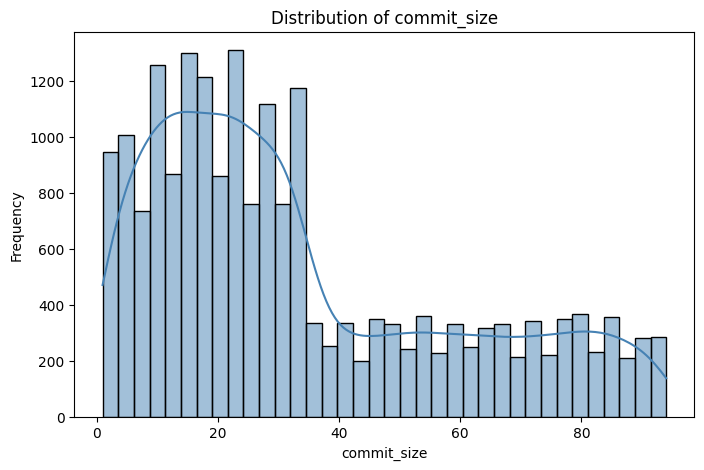

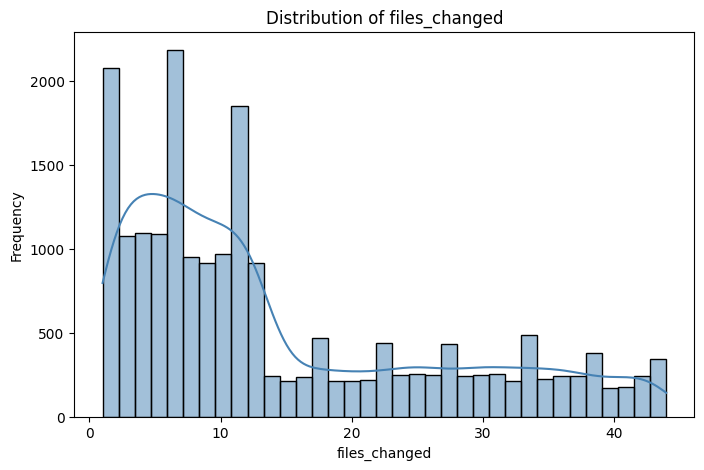

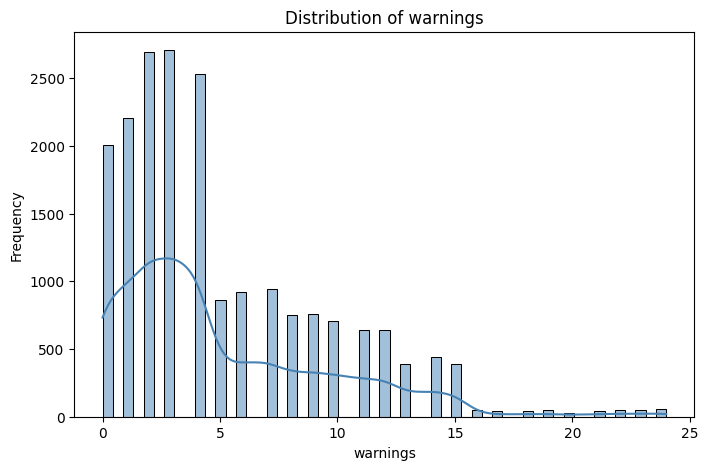

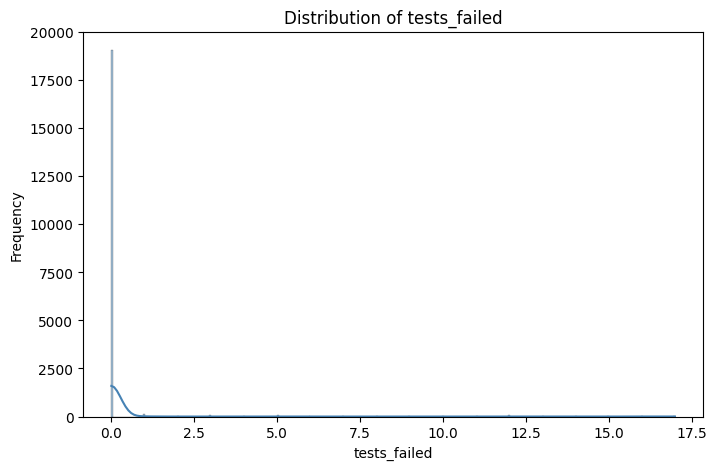

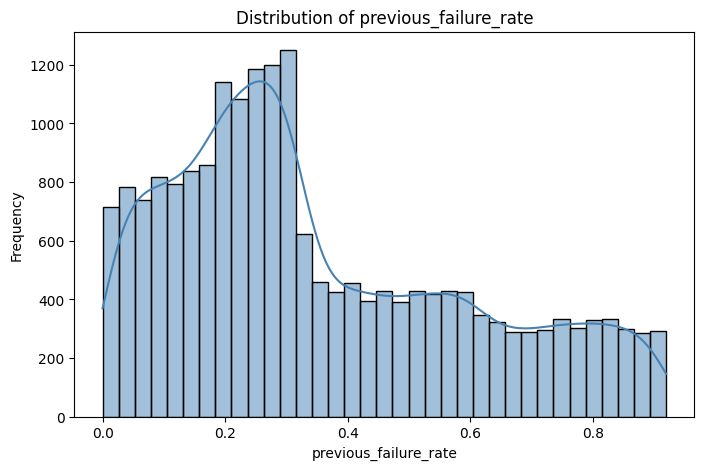

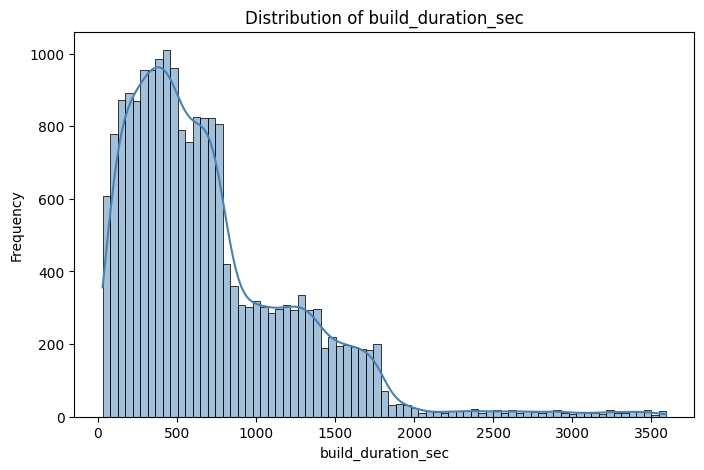

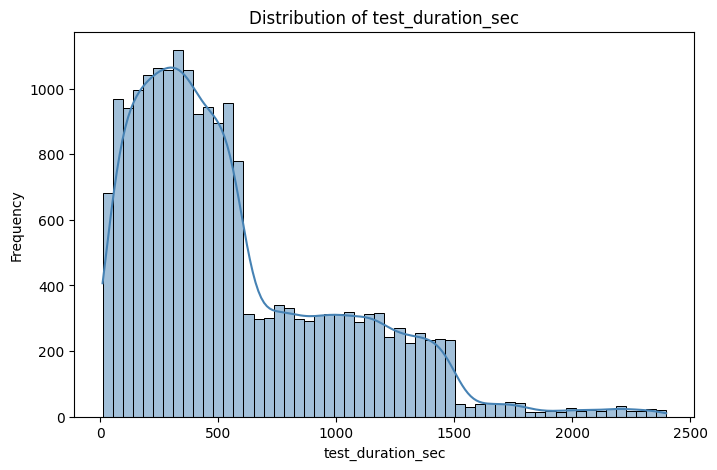

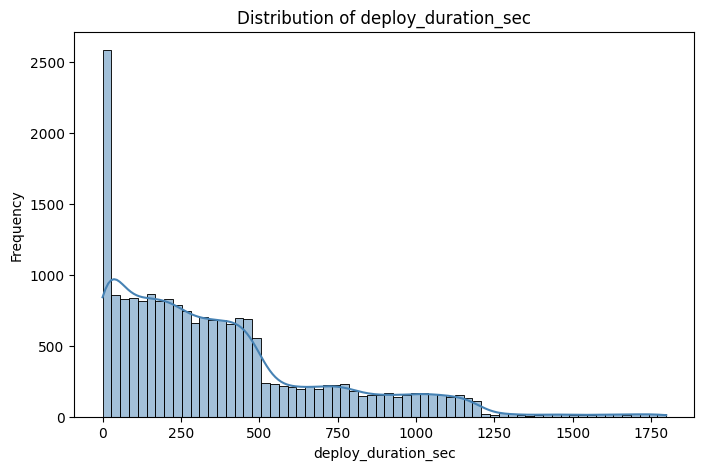

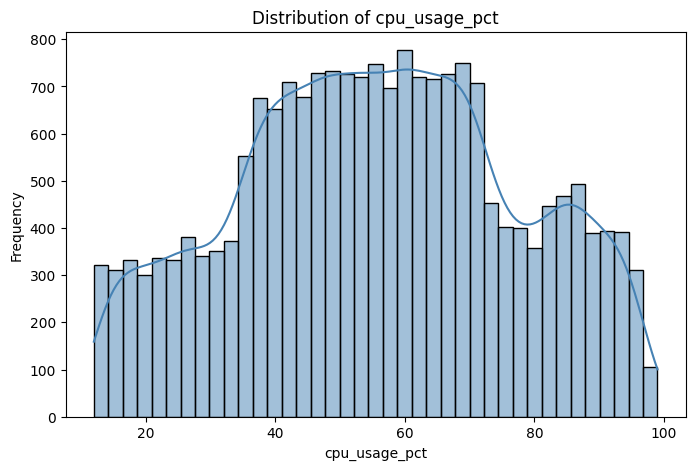

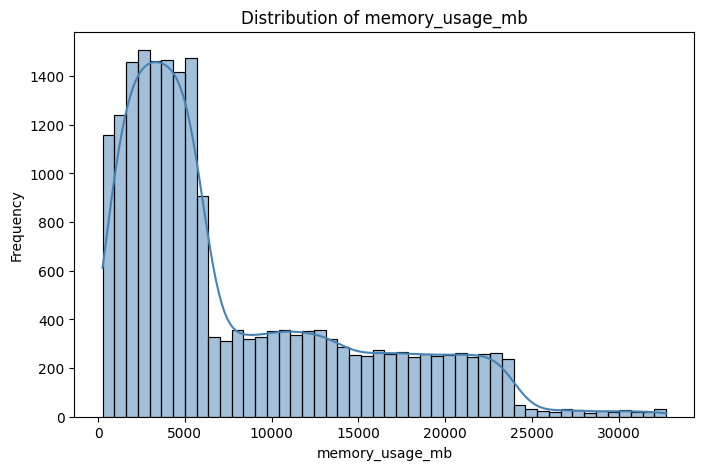

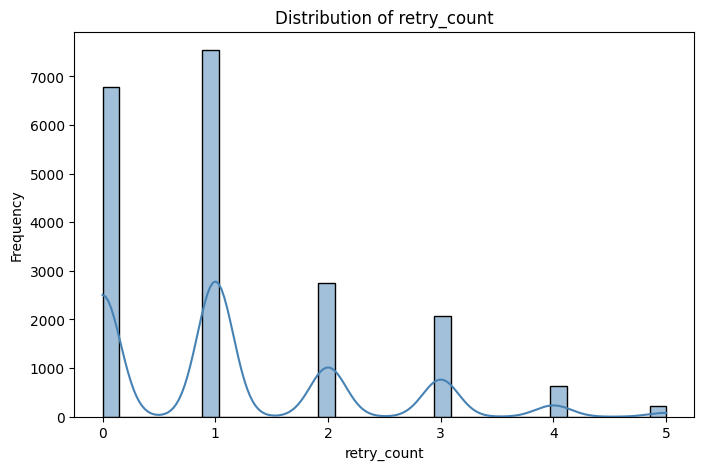

In [20]:
for column in numerical_features:
    plt.figure(figsize=(8,5))

    sns.histplot(df[column], kde=True, color='steelblue')

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [21]:
pipeline_summary = df.groupby('result')[numerical_features].mean()

pipeline_summary

,commit_size,files_changed,warnings,tests_failed,previous_failure_rate,build_duration_sec,test_duration_sec,deploy_duration_sec,cpu_usage_pct,memory_usage_mb,retry_count
result,,,,,,,,,,,
FAIL,42.9407,18.9341,7.2445,0.7768,0.500312,934.8095,774.3568,460.0477,65.486599,12044.1390,1.7100
PASS,23.7518,9.6387,2.9785,0.0000,0.202882,482.0457,363.7279,272.6427,45.938667,3853.0491,0.5768


In [22]:
main_features = [
    'warnings',
    'previous_failure_rate',
    'build_duration_sec',
    'test_duration_sec',
    'memory_usage_mb',
    'retry_count'
]

main_features

['warnings',
 'previous_failure_rate',
 'build_duration_sec',
 'test_duration_sec',
 'memory_usage_mb',
 'retry_count']

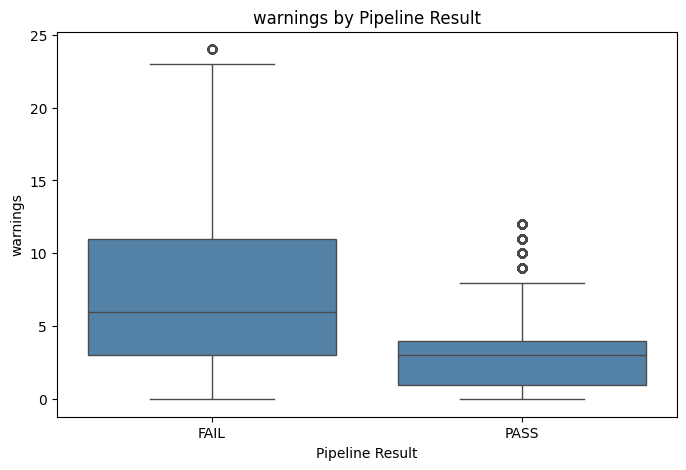

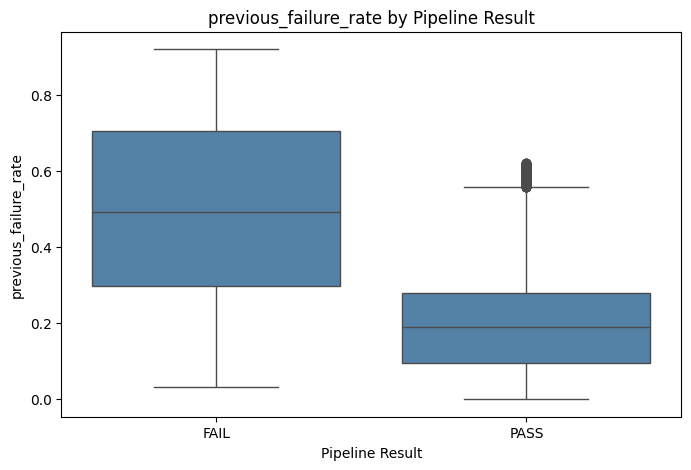

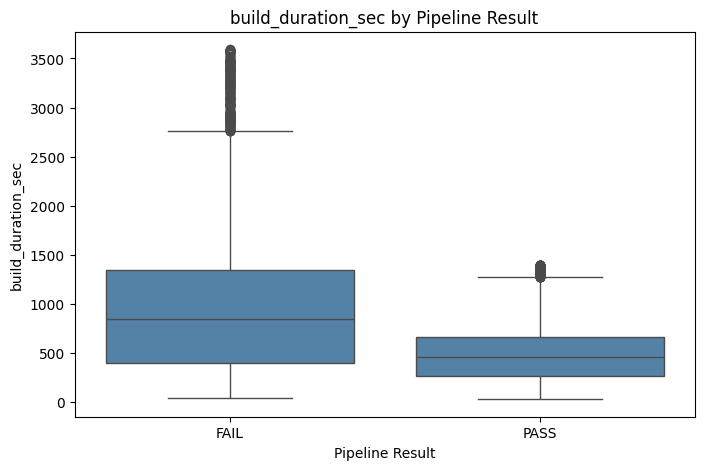

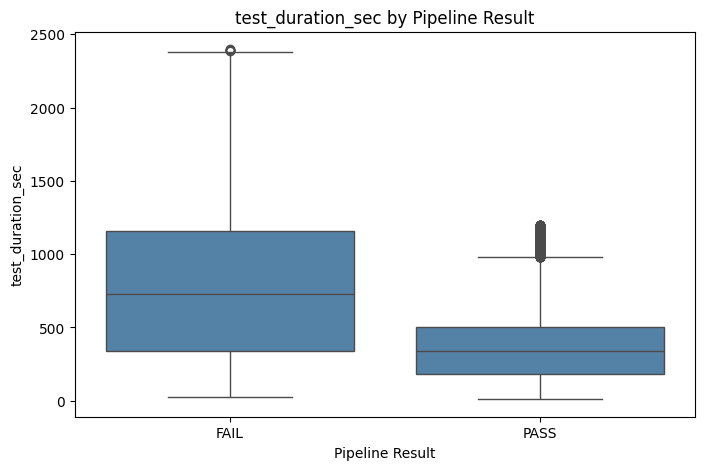

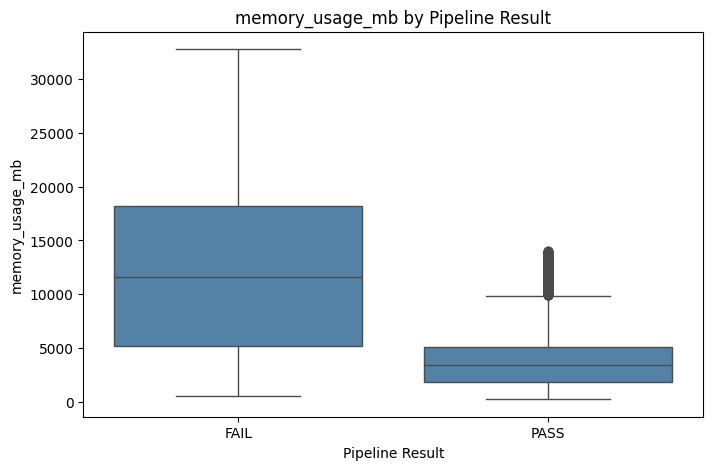

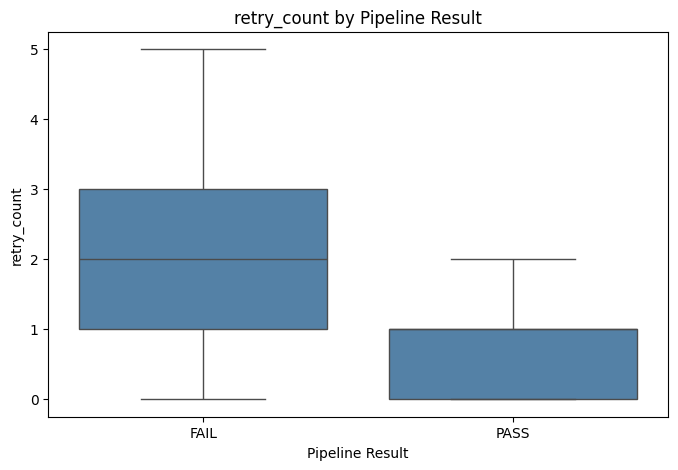

In [23]:
for column in main_features:
    plt.figure(figsize=(8,5))

    sns.boxplot(x='result', y=column, data=df, color='steelblue')

    plt.title(column + " by Pipeline Result")
    plt.xlabel("Pipeline Result")
    plt.ylabel(column)
    plt.show()

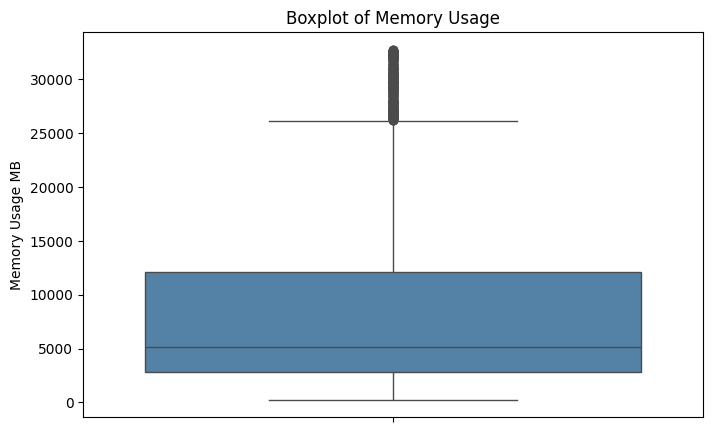

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(y='memory_usage_mb', data=df, color='steelblue')

plt.title("Boxplot of Memory Usage")
plt.ylabel("Memory Usage MB")
plt.show()

In [25]:
q1 = df['memory_usage_mb'].quantile(0.25)
q3 = df['memory_usage_mb'].quantile(0.75)

iqr = q3 - q1

ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

print(q1, q3, iqr, ul, ll)

2802.0 12140.5 9338.5 26148.25 -11205.75


In [26]:
memory_outliers = df[
    ((df['memory_usage_mb'] < ll) | (df['memory_usage_mb'] > ul))
]

memory_outliers[
    ['memory_usage_mb', 'cpu_usage_pct', 'warnings', 'result']
].head(10)

,memory_usage_mb,cpu_usage_pct,warnings,result
221,28444,85.81,14,FAIL
405,28443,90.44,4,FAIL
481,26457,88.84,10,FAIL
509,31654,87.18,3,FAIL
558,32370,87.46,11,FAIL
658,28787,98.12,11,FAIL
940,26968,89.53,7,FAIL
996,30391,93.96,4,FAIL
1031,29264,87.95,3,FAIL
1080,29466,94.71,7,FAIL


In [27]:
memory_outliers.shape

(228, 31)

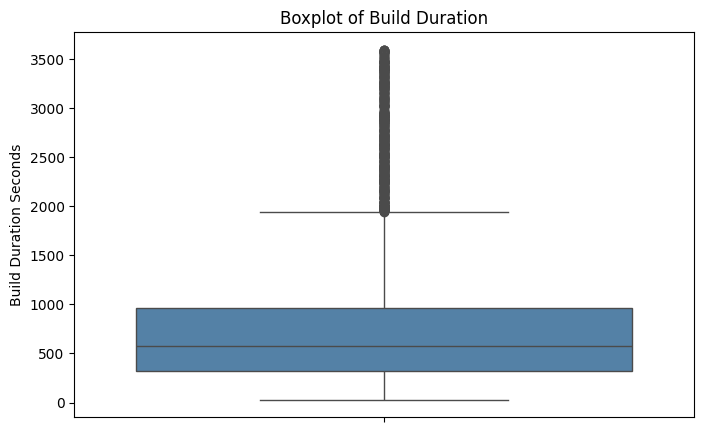

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(y='build_duration_sec', data=df, color='steelblue')

plt.title("Boxplot of Build Duration")
plt.ylabel("Build Duration Seconds")
plt.show()

In [29]:
q1 = df['build_duration_sec'].quantile(0.25)
q3 = df['build_duration_sec'].quantile(0.75)

iqr = q3 - q1

ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

print(q1, q3, iqr, ul, ll)

build_duration_outliers = df[
    ((df['build_duration_sec'] < ll) | (df['build_duration_sec'] > ul))
]

318.0 968.0 650.0 1943.0 -657.0


In [30]:
build_duration_outliers.shape

(475, 31)

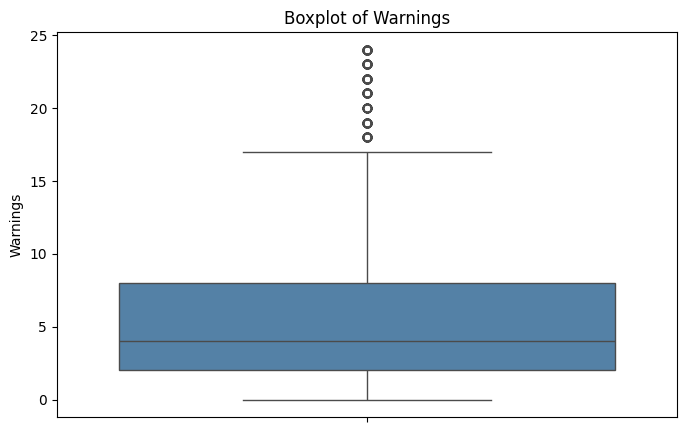

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(y='warnings', data=df, color='steelblue')

plt.title("Boxplot of Warnings")
plt.ylabel("Warnings")
plt.show()

In [32]:
q1 = df['warnings'].quantile(0.25)
q3 = df['warnings'].quantile(0.75)

iqr = q3 - q1

ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

print(q1, q3, iqr, ul, ll)

warning_outliers = df[
    ((df['warnings'] < ll) | (df['warnings'] > ul))
]

warning_outliers.shape

2.0 8.0 6.0 17.0 -7.0


(322, 31)

In [33]:
for column in numerical_features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    ul = q3 + 1.5*iqr
    ll = q1 - 1.5*iqr

    outliers = df[
        ((df[column] < ll) | (df[column] > ul))
    ]

    print(column, outliers.shape[0])

commit_size 0
files_changed 0
warnings 322
tests_failed 936
previous_failure_rate 0
build_duration_sec 475
test_duration_sec 379
deploy_duration_sec 1016
cpu_usage_pct 0
memory_usage_mb 228
retry_count 0


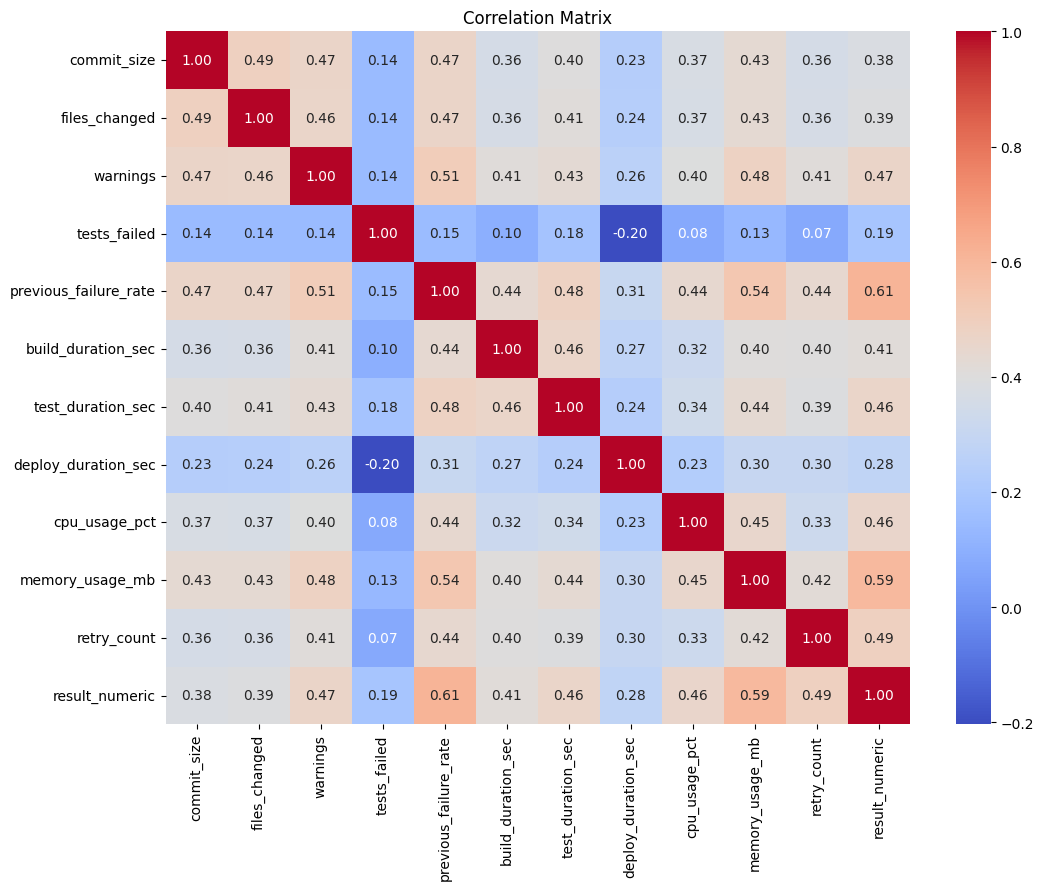

In [34]:
correlation_data = df[numerical_features].copy()
correlation_data['result_numeric'] = df['result'].map({
    'PASS': 0,
    'FAIL': 1
})

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12,9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [35]:
df['ci_tool'].value_counts()

ci_tool
GitHub Actions    6448
GitLab CI         3503
Jenkins           3389
Azure DevOps      3349
CircleCI          3311
Name: count, dtype: int64

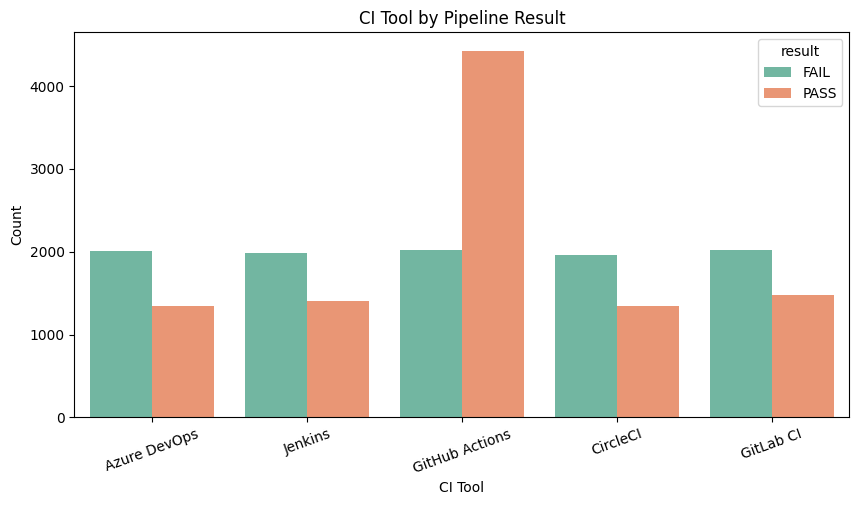

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='ci_tool',
    hue='result',
    data=df,
    palette='Set2'
)

plt.title("CI Tool by Pipeline Result")
plt.xlabel("CI Tool")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [37]:
df['language'].value_counts()

language
NodeJS    3447
C++       3384
Java      3345
Rust      3337
Python    3266
Go        3221
Name: count, dtype: int64

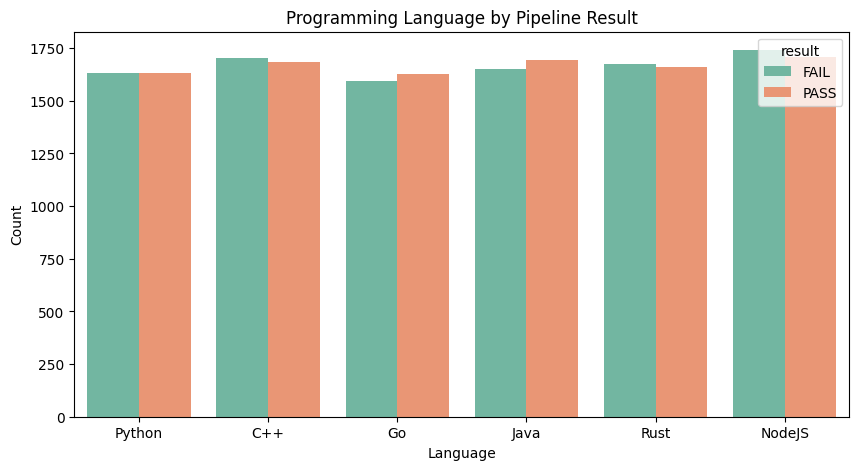

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='language',
    hue='result',
    data=df,
    palette='Set2'
)

plt.title("Programming Language by Pipeline Result")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

In [39]:
print("Cloud provider missing values:")
print(df['cloud_provider'].isnull().sum())

print("\nTarget balance:")
print(df['result'].value_counts())

print("\nSelected model features:")
print(len(feature_columns))

Cloud provider missing values:
732

Target balance:
result
FAIL    10000
PASS    10000
Name: count, dtype: int64

Selected model features:
16
